In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

final_df_metric = {}
metrics = ["hrm", "pozzi"]

for metric in metrics:
    final_df_metric[metric] = pd.read_parquet(f"../../data/07_portfolios_metadata/complete_metadata_{metric}.parquet")

## Sector

Gerando Heatmap para a métrica: HRM


/tmp/ipykernel_95482/2247177919.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["portfolio", "year", "Sector"])


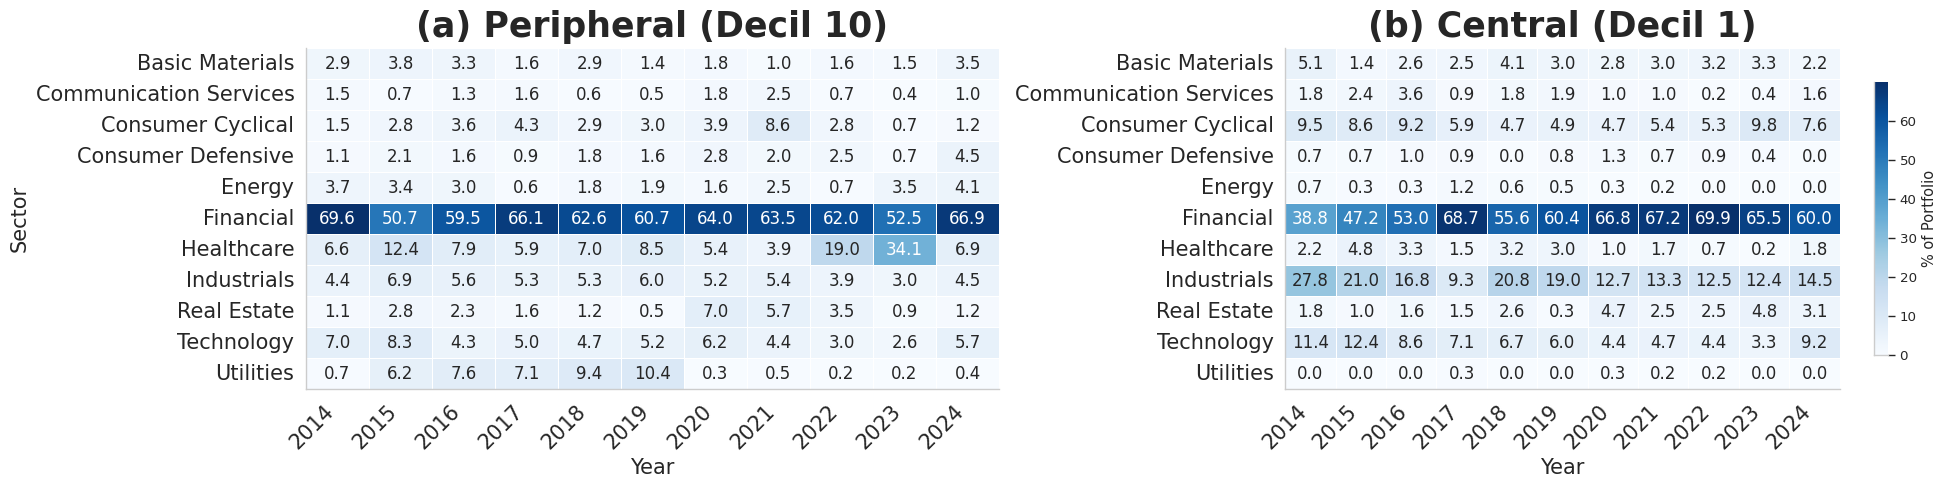

Gerando Heatmap para a métrica: POZZI


/tmp/ipykernel_95482/2247177919.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["portfolio", "year", "Sector"])


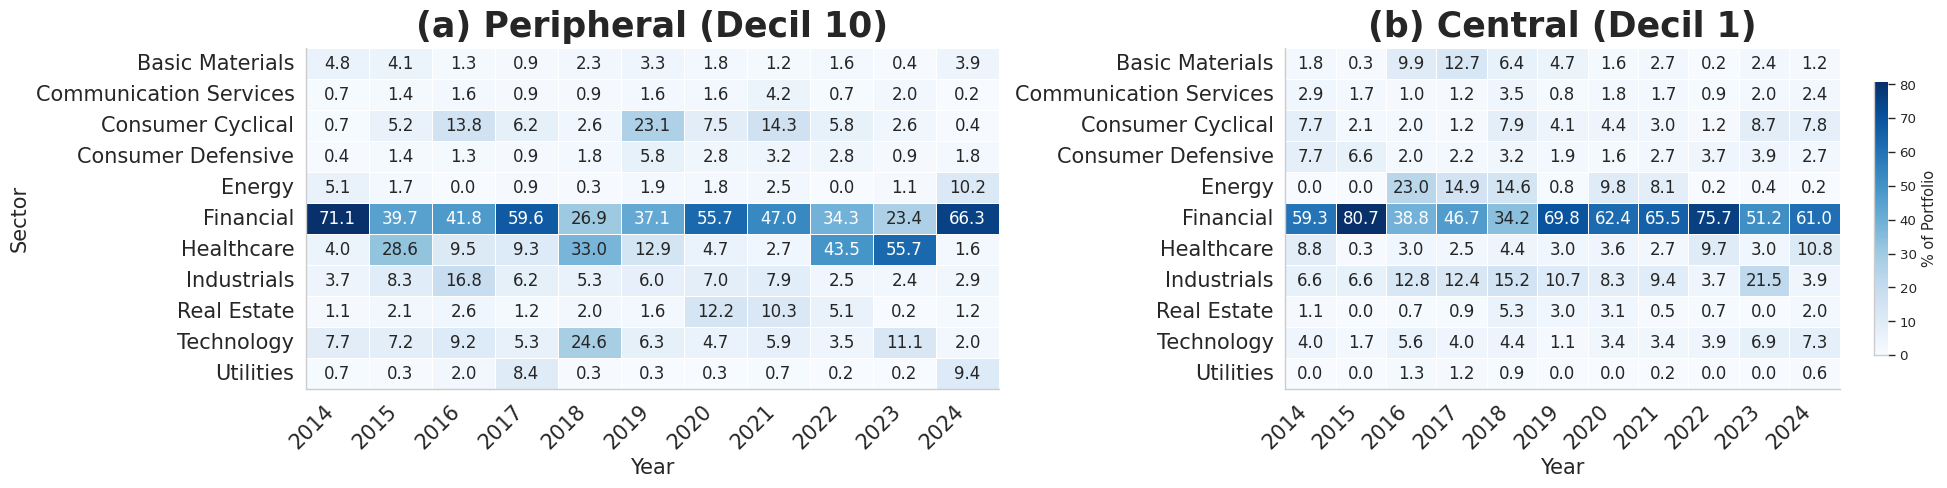

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Carregamento (como você definiu)
final_df_metric = {}
metrics = ["hrm", "pozzi"]

for metric in metrics:
    final_df_metric[metric] = pd.read_parquet(f"../../data/07_portfolios_metadata/complete_metadata_{metric}.parquet")

# --- Início da adaptação do plot ---

for metric, final_df in final_df_metric.items():
    print(f"Gerando Heatmap para a métrica: {metric.upper()}")
    
    sector_counts = (
        final_df
        .groupby(["portfolio", "year", "Sector"])
        .size()
        .reset_index(name="n_firms")
    )

    all_sectors = sorted(
        sector_counts["Sector"].unique().tolist()
    )

    # --- Compute sector % share per portfolio/year ---
    def pct_pivot(portfolio_label):
        piv = (
            sector_counts
            .query("portfolio == @portfolio_label")
            .pivot_table(index="Sector", columns="year", values="n_firms", fill_value=0)
            .reindex(index=all_sectors, fill_value=0)
        )
        # Normalize each year to 100%
        return piv.div(piv.sum(axis=0), axis=1) * 100

    # No nosso novo contexto: decil_1 é central e decil_10 é peripheral
    central_pct    = pct_pivot("decil_1")
    peripheral_pct = pct_pivot("decil_10")

    # --- Plot ---
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

    fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=False)

    for ax, df_pct, title, cbar in zip(
        axes,
        [peripheral_pct, central_pct],
        ["(a) Peripheral (Decil 10)", "(b) Central (Decil 1)"],
        [False, True],
    ):
        sns.heatmap(
            df_pct,
            ax=ax,
            annot=True,
            fmt=".1f",
            cmap="Blues",
            linewidths=0.4,
            linecolor="white",
            cbar=cbar,
            cbar_kws={"label": "% of Portfolio", "shrink": 0.8} if cbar else {},
            annot_kws={"fontsize": 12},
        )
        ax.set_title(title, fontsize=25, fontweight="bold", pad=8)
        ax.set_xlabel("Year", fontsize=15)
        ax.set_ylabel("Sector" if ax == axes[0] else "", fontsize=15)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=15)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=15)

    sns.despine(fig=fig)
    plt.tight_layout()
    
    # Cria a pasta figures se não existir
    Path("../../figures").mkdir(parents=True, exist_ok=True)
    
    # Salva o arquivo diferenciando a métrica no nome da imagem
    plt.savefig(f"../../figures/sector_composition_heatmap_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Boxplots

Gerando Painel de Métricas para HRM...


/tmp/ipykernel_95482/3124904935.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_95482/3124904935.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_95482/3124904935.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_95482/3124904935.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_95482/3124904935.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has bee

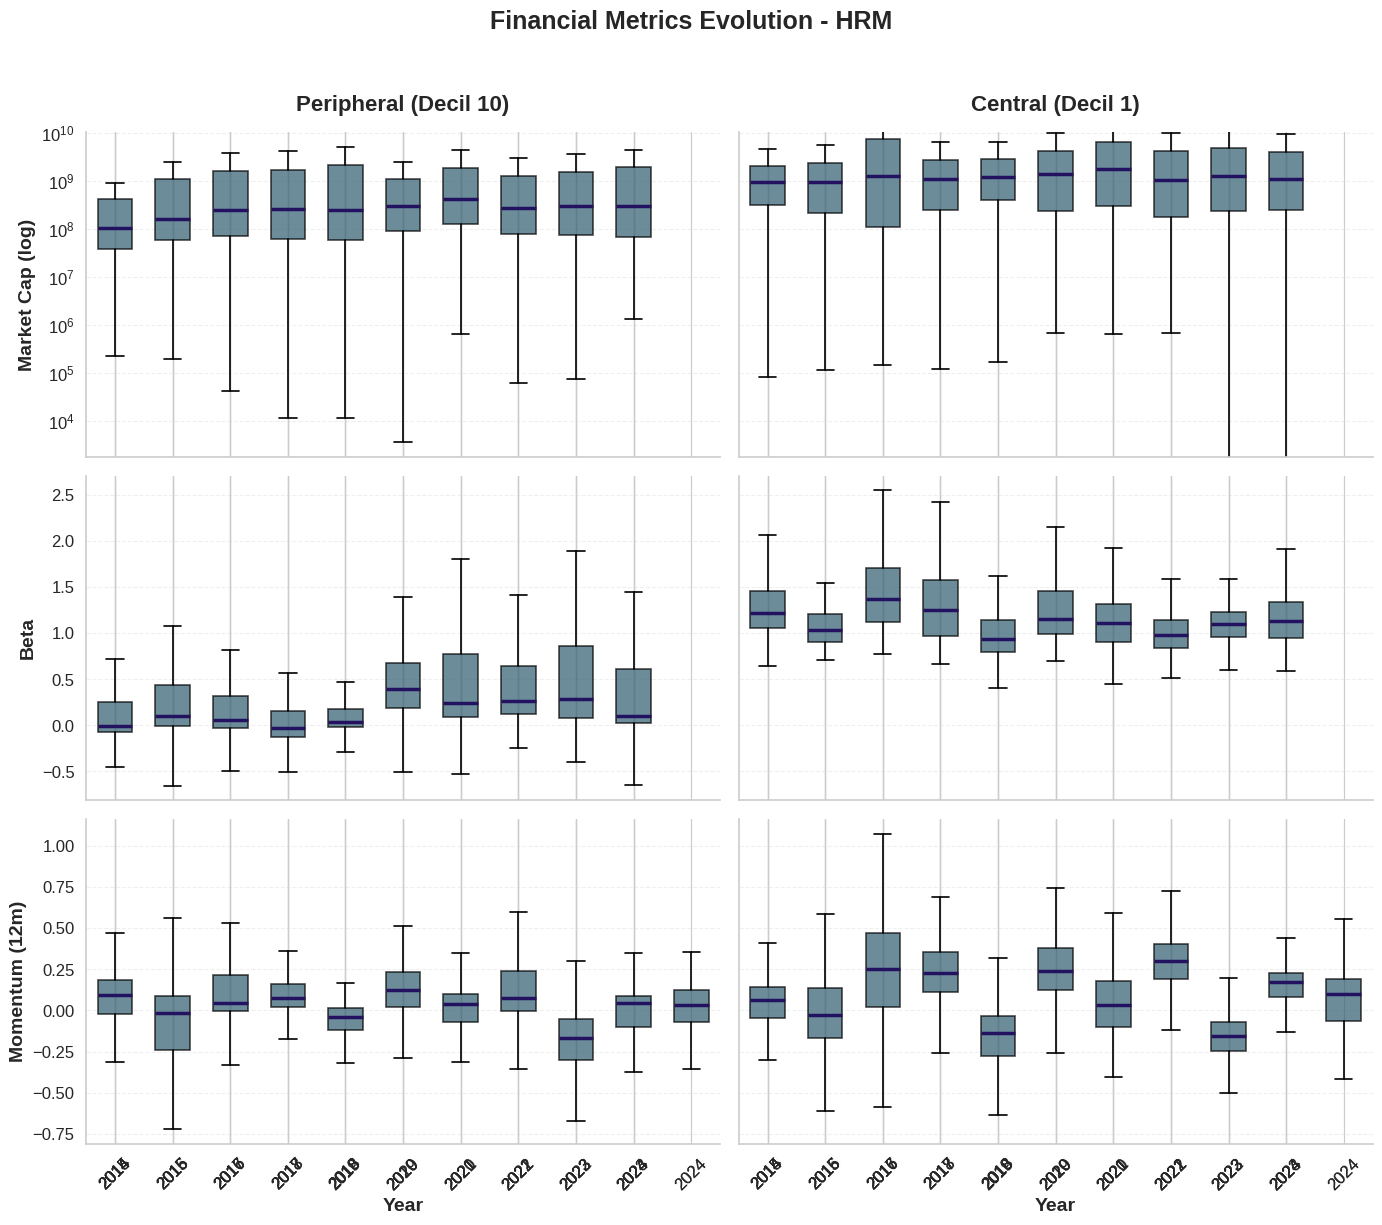

Gerando Painel de Métricas para POZZI...


/tmp/ipykernel_95482/3124904935.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_95482/3124904935.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_95482/3124904935.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_95482/3124904935.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_95482/3124904935.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has bee

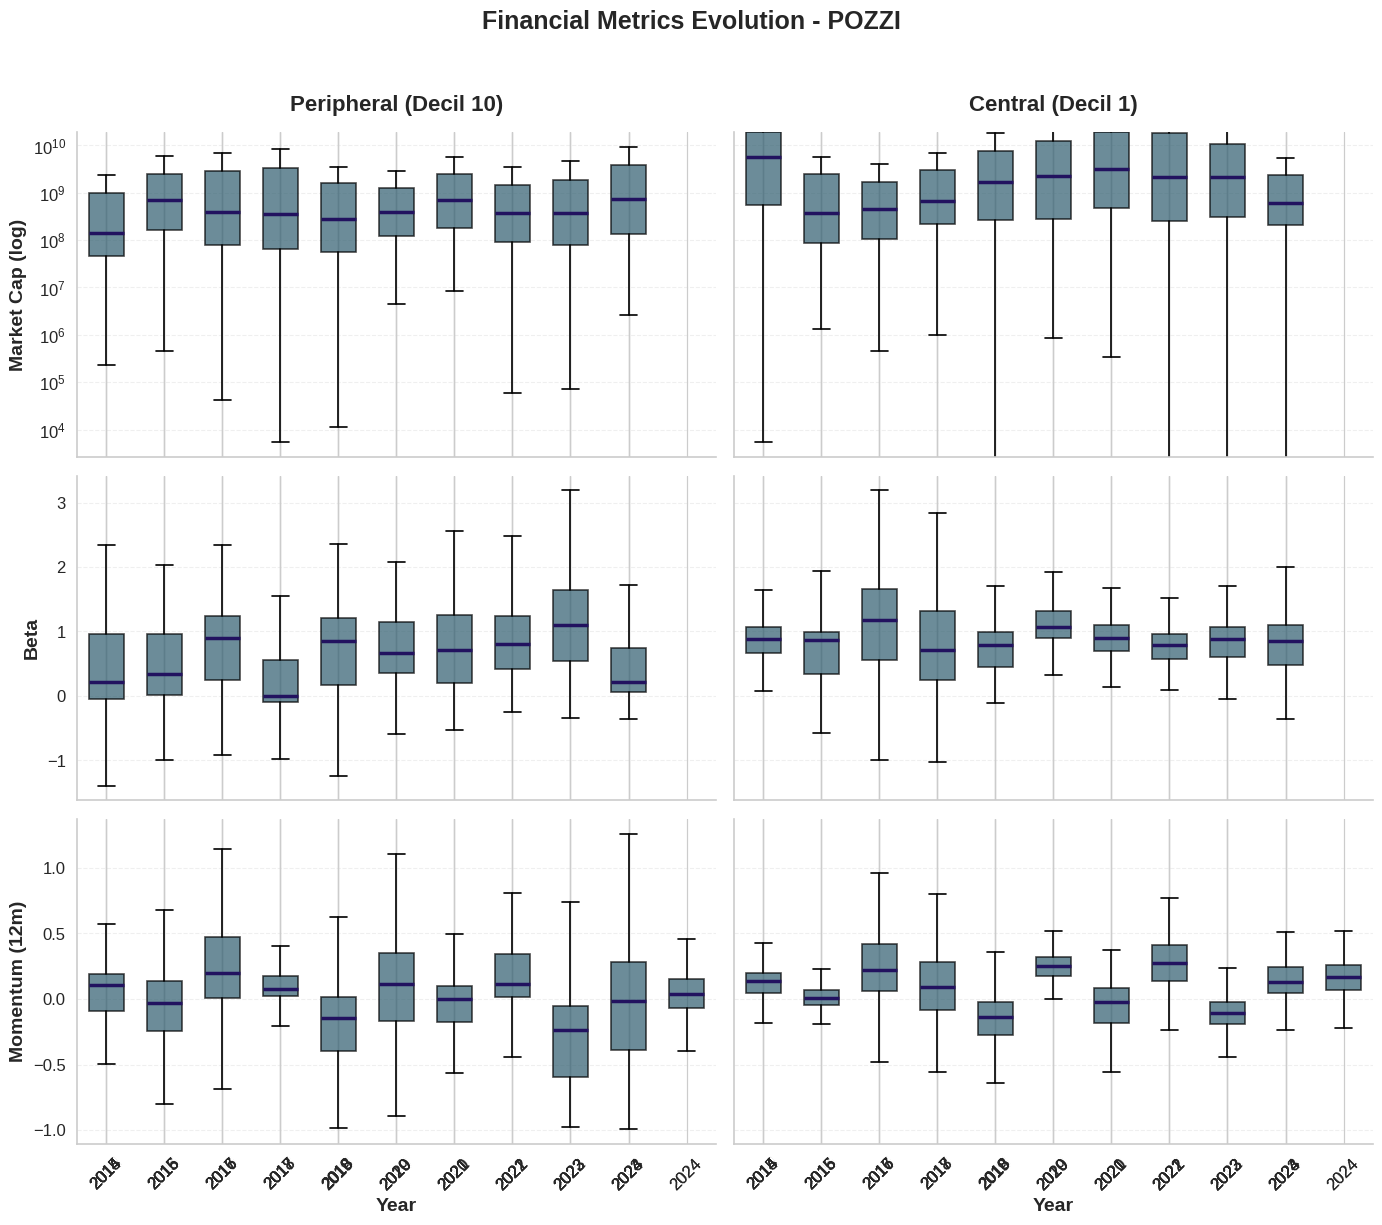

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def plot_combined_metrics_evolution(
    df,
    network_metric_name,
    portfolios=None,
    figsize=(14, 12),
    showfliers=False,
    save=False,
    out_dir="../../figures",
    dpi=300
):
    """
    Gera um painel 3x2 com a evolução de Market Cap, Beta e Momentum
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_context("paper", font_scale=1.3)
    
    if portfolios is None:
        portfolios = ['decil_10', 'decil_1']
        
    portfolio_titles = {
        'decil_10': 'Peripheral (Decil 10)',
        'decil_1': 'Central (Decil 1)'
    }
    
    # Configuração das 3 métricas
    metrics_info = [
        {'prefix': 'mcap',     'label': 'Market Cap (log)', 'log': True},
        {'prefix': 'beta',     'label': 'Beta',             'log': False},
        {'prefix': 'momentum', 'label': 'Momentum (12m)',   'log': False}
    ]
    
    fig, axes = plt.subplots(3, 2, figsize=figsize, sharex=True)
    
    box_color = '#2E5C6E'
    median_color = "#22125F"
    TITLE_SIZE = 16
    LABEL_SIZE = 14
    TICK_SIZE = 12
    
    for row_idx, m_info in enumerate(metrics_info):
        prefix = m_info['prefix']
        log_scale = m_info['log']
        y_label = m_info['label']
        
        # 1. Filtra e derrete (melt) os dados da métrica atual
        metric_cols = df.columns[df.columns.str.match(fr"^{prefix}_\d{{4}}$")].tolist()
        if not metric_cols:
            continue
            
        metric_long = df.melt(
            id_vars=["Ticker", "portfolio"], value_vars=metric_cols,
            var_name="metric_year", value_name="value"
        )
        metric_long["year"] = metric_long["metric_year"].str.replace(f"{prefix}_", "", regex=False).astype(int)
        metric_long = metric_long.dropna(subset=["value"])
        
        # 2. Plota os dois decis (colunas)
        for col_idx, portfolio in enumerate(portfolios):
            ax = axes[row_idx, col_idx]
            
            data_p = metric_long[metric_long["portfolio"] == portfolio]
            years = sorted(data_p["year"].unique())
            boxplot_data = [data_p[data_p["year"] == y]["value"].values for y in years]
            
            ax.boxplot(
                boxplot_data, labels=years, patch_artist=True, showfliers=showfliers, widths=0.6,
                medianprops=dict(color=median_color, linewidth=2.5),
                boxprops=dict(facecolor=box_color, edgecolor='black', linewidth=1.2, alpha=0.7),
                whiskerprops=dict(color='black', linewidth=1.2),
                capprops=dict(color='black', linewidth=1.2),
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
            )
            
            if log_scale:
                ax.set_yscale("log")
                
            # Estilização
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(1.2)
            ax.spines['bottom'].set_linewidth(1.2)
            ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.8)
            ax.set_axisbelow(True)
            ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE, width=1.2)
            
            # Textos e Eixos
            if row_idx == 2: # Na última linha, coloca os anos
                ax.tick_params(axis='x', rotation=45)
                ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold")
                
            if col_idx == 0: # Na primeira coluna, coloca o nome da métrica
                ax.set_ylabel(y_label, fontsize=LABEL_SIZE, fontweight="bold")
                
            if row_idx == 0: # Na primeira linha, coloca o título do Decil
                p_title = portfolio_titles.get(portfolio, portfolio.capitalize())
                ax.set_title(p_title, fontsize=TITLE_SIZE, fontweight="bold", pad=15)
                
        # Sincroniza o eixo Y entre o Central e Peripheral para a métrica atual
        axes[row_idx, 1].sharey(axes[row_idx, 0])
        plt.setp(axes[row_idx, 1].get_yticklabels(), visible=False)

    fig.suptitle(f"Financial Metrics Evolution - {network_metric_name.upper()}", 
                 fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout()
    
    if save:
        out_path = Path(out_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        filename = f"combined_metrics_evolution_{network_metric_name}.png"
        fig.savefig(out_path / filename, dpi=dpi, bbox_inches="tight", facecolor='white', edgecolor='none')

    plt.show()

# --- Chamada do Loop ---
for metric, df in final_df_metric.items():
    print(f"Gerando Painel de Métricas para {metric.upper()}...")
    plot_combined_metrics_evolution(
        df=df,
        network_metric_name=metric,
        save=True,
        out_dir="../../figures"  # Vai salvar como combined_metrics_evolution_hrm.png e _pozzi.png
    )

## Composition

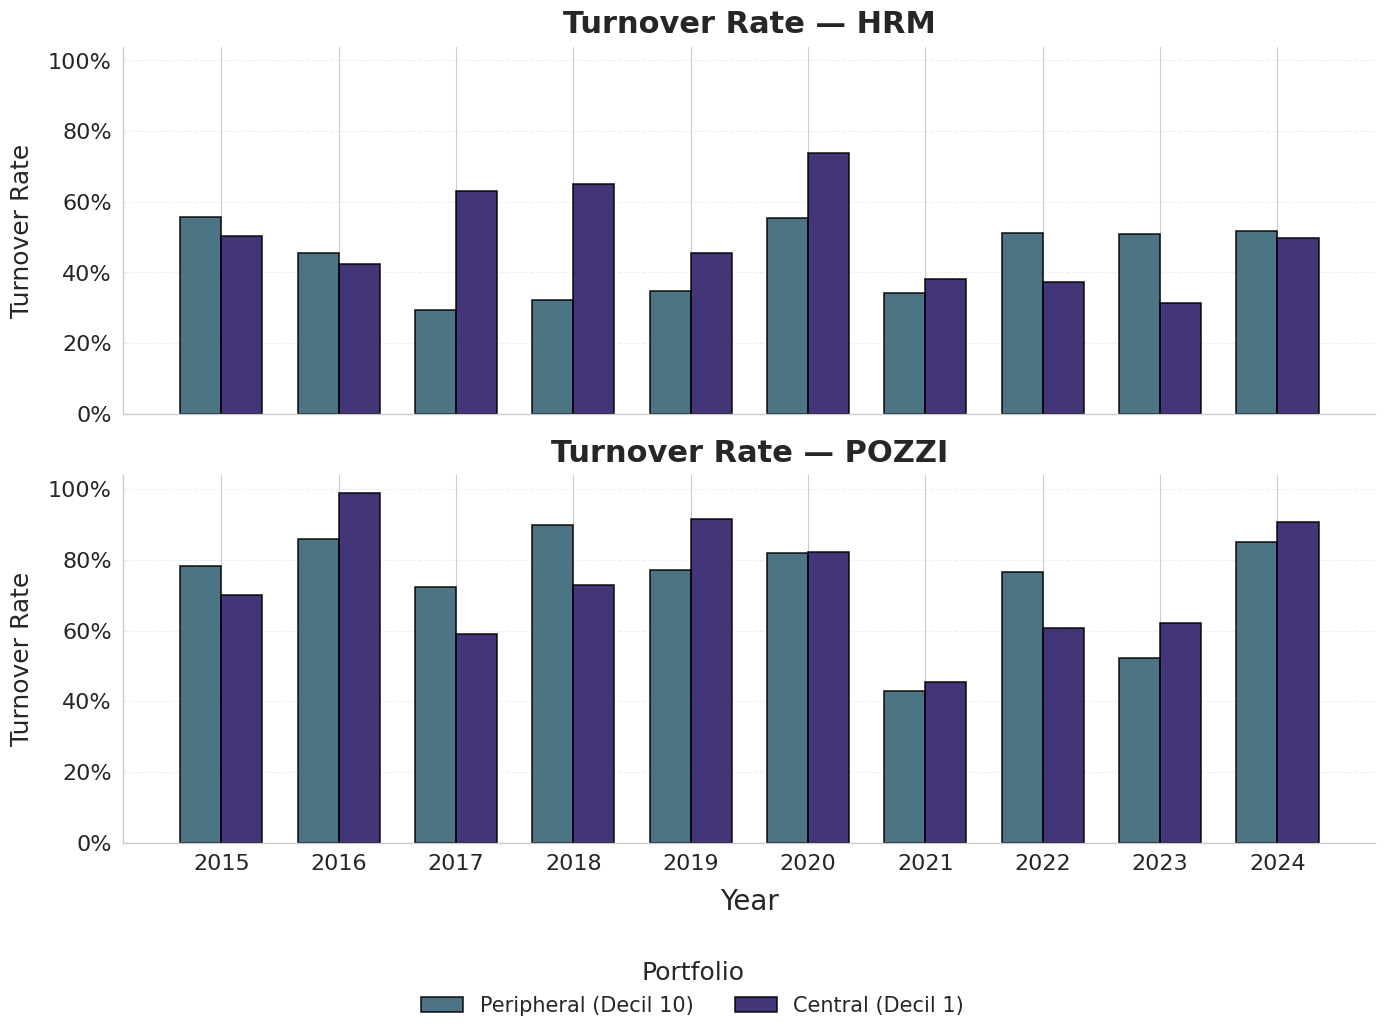

In [13]:
# 2. Plot do Turnover em Grade 2x1 (HRM em cima, Pozzi em baixo) com a sua paleta customizada
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- AQUI ESTÁ A MÁGICA DAS CORES DO SEU OUTRO GRÁFICO ---
# Usando o box_color para Peripheral e o median_color para Central (ou vice-versa)
palette = ['#2E5C6E', '#22125F'] 

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)
metrics = ["hrm", "pozzi"]

for ax, metric in zip(axes, metrics):
    turnover_df = turnover_df_metric[metric]
    
    width = 0.35
    years = sorted(turnover_df["year"].unique())
    x = range(len(years))
    offsets = [-width / 2, width / 2]

    portfolios_to_plot = ["decil_10", "decil_1"]
    labels_to_plot = ["Peripheral (Decil 10)", "Central (Decil 1)"]

    for i, (portfolio_code, label) in enumerate(zip(portfolios_to_plot, labels_to_plot)):
        group = turnover_df[turnover_df["portfolio"] == portfolio_code].sort_values("year")
        ax.bar(
            [xi + offsets[i] for xi in x], group["turnover_rate"],
            width=width, 
            color=palette[i], # Aplica as cores exatas aqui
            alpha=0.85,
            label=label,
            edgecolor='black', # Bordinha preta pra ficar igual ao boxplot
            linewidth=1.2
        )

    ax.set_xticks(x)
    
    # Aplica as datas apenas no eixo X do gráfico de baixo
    if ax == axes[-1]:
        ax.set_xticklabels(years, rotation=0, fontsize=15)
        ax.set_xlabel("Year", fontsize=20, labelpad=10)
        
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1, decimals=0))
    ax.set_title(f"Turnover Rate — {metric.upper()}", fontsize=22, fontweight="bold", pad=10)
    ax.tick_params(axis="both", labelsize=16)
    
    # Label Y em ambos os eixos
    ax.set_ylabel("Turnover Rate", fontsize=18, labelpad=10)
    
    # Grid estilizado igual ao do boxplot
    ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.8)
    ax.set_axisbelow(True)

# Extrai a legenda do primeiro subplot
handles, labels = axes[0].get_legend_handles_labels()

# Legenda unificada no rodapé
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
           ncol=2, title="Portfolio", title_fontsize=18, fontsize=15, frameon=False)

sns.despine(fig=fig)
plt.tight_layout()

# Espaço no fundo para a legenda não sobrepor
plt.subplots_adjust(bottom=0.15) 

Path("../../figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../../figures/turnover_evolution_hrm_pozzi.png", dpi=300, bbox_inches="tight")
plt.show()
